In [1]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

Using Colab cache for faster access to the 'fer2013' dataset.


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight

CONFIG

In [3]:
IMG_SIZE = 96          # MobileNet minimum
BATCH_SIZE = 128
EPOCHS = 40
LR = 1e-4
NUM_CLASSES = 7

train_dir = "/kaggle/input/fer2013/train"
val_dir   = "/kaggle/input/fer2013/test"


DATA GENERATORS (RGB REQUIRED)

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",     # IMPORTANT
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


 CLASS WEIGHTS

In [5]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))


 BASE MODEL (MobileNetV2)

In [6]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Phase 1: freeze backbone

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


CUSTOM HEAD

In [7]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

CALLBACKS

In [8]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-6)
]


TRAIN (PHASE 1)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.1891 - loss: 2.2293 - val_accuracy: 0.2906 - val_loss: 1.7966 - learning_rate: 1.0000e-04
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 479ms/step - accuracy: 0.2703 - loss: 1.8210 - val_accuracy: 0.3317 - val_loss: 1.7190 - learning_rate: 1.0000e-04
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 482ms/step - accuracy: 0.3025 - loss: 1.7515 - val_accuracy: 0.3373 - val_loss: 1.6998 - learning_rate: 1.0000e-04
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 479ms/step - accuracy: 0.3194 - loss: 1.6878 - val_accuracy: 0.3693 - val_loss: 1.6494 - learning_rate: 1.0000e-04
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 479ms/step - accuracy: 0.3386 - loss: 1.6883 - val_accuracy: 0.3805 - val_loss: 1.6197 - learning_rate: 1.0000e-04
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 108s 482ms/step - accuracy: 0.3429 - loss: 1.6524 - val_accuracy: 0.3618 - val_loss: 1.6505 - learning_rate: 1.0000e-04
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 108

FINE-TUNING (PHASE 2)


In [10]:
print("Fine-tuning MobileNetV2...")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)

Fine-tuning MobileNetV2...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 137s 529ms/step - accuracy: 0.2790 - loss: 2.5094 - val_accuracy: 0.4053 - val_loss: 1.5715 - learning_rate: 1.0000e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 105s 469ms/step - accuracy: 0.3281 - loss: 1.8672 - val_accuracy: 0.3842 - val_loss: 1.6445 - learning_rate: 1.0000e-05
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 104s 464ms/step - accuracy: 0.3437 - loss: 1.7079 - val_accuracy: 0.3982 - val_loss: 1.5962 - learning_rate: 1.0000e-05
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 103s 459ms/step - accuracy: 0.3539 - loss: 1.6568 - val_accuracy: 0.4051 - val_loss: 1.5595 - learning_rate: 1.0000e-05
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 106s 470ms/step - accuracy: 0.3618 - loss: 1.5839 - val_accuracy: 0.4062 - val_loss: 1.5409 - learning_rate: 1.0000e-05
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 106s 472ms/step - accuracy: 0.3679 - loss: 1.5690 - val_accuracy: 0.4166 - val_loss: 1.5164 - learning_rate: 1.0000e-05
Epoch 7/20
22

In [ ]:
model.save("mobilenet_emotion_model.keras")

Plot Training Curves

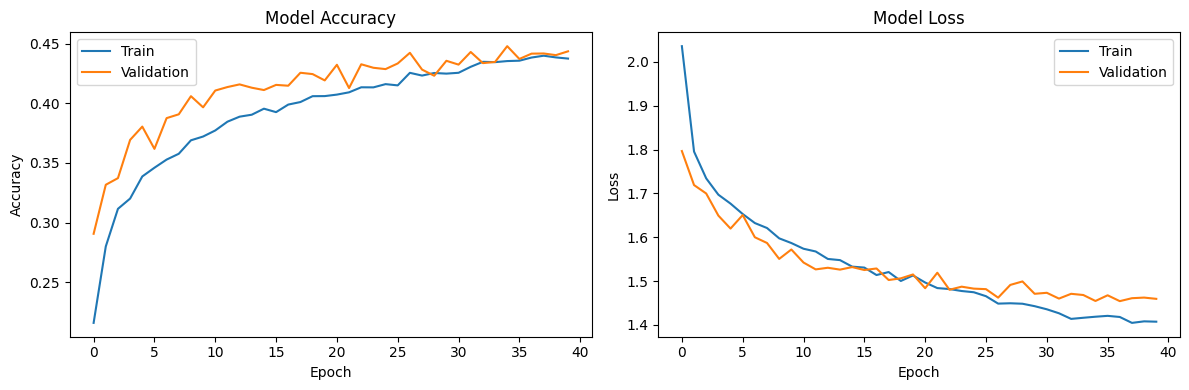

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate on Test Set

Model input shape: (None, 96, 96, 3)
Found 7178 images belonging to 7 classes.
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step

Classification Report:

              precision    recall  f1-score   support

       angry       0.35      0.29      0.31       958
     disgust       0.20      0.49      0.28       111
        fear       0.38      0.16      0.22      1024
       happy       0.75      0.57      0.65      1774
     neutral       0.39      0.53      0.45      1233
         sad       0.34      0.48      0.40      1247
    surprise       0.56      0.65      0.60       831

    accuracy                           0.46      7178
   macro avg       0.42      0.45      0.42      7178
weighted avg       0.48      0.46      0.45      7178



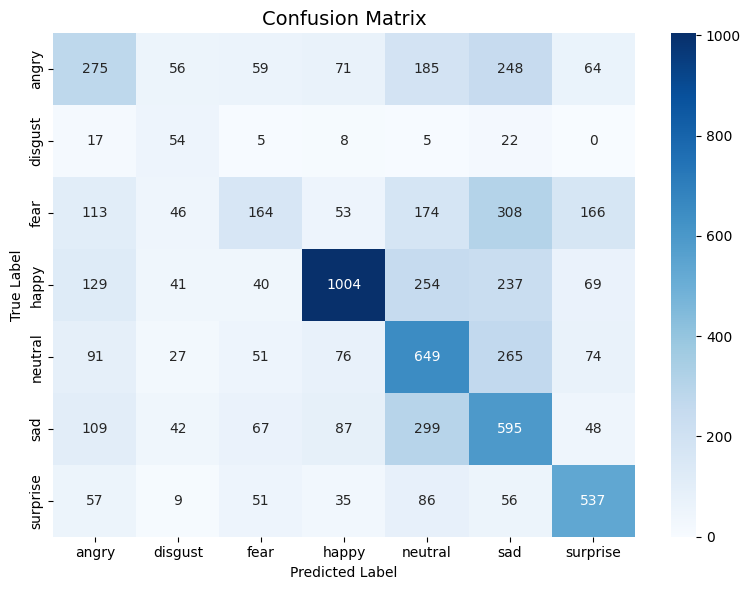

Per-Class Accuracy:
angry: 28.71%
disgust: 48.65%
fear: 16.02%
happy: 56.60%
neutral: 52.64%
sad: 47.71%
surprise: 64.62%


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# LOAD MODEL (MobileNet)
# -----------------------------
model = load_model('mobilenet_emotion_model.keras')

print("Model input shape:", model.input_shape)
# Expected: (None, 96, 96, 3)

# -----------------------------
# TEST DATA GENERATOR (MUST MATCH MODEL)
# -----------------------------
test_datagen_eval = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen_eval.flow_from_directory(
    '/kaggle/input/fer2013/test',
    target_size=(96, 96),      # ✅ FIXED
    color_mode='rgb',          # ✅ FIXED
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# -----------------------------
# PER-CLASS ACCURACY
# -----------------------------
print("Per-Class Accuracy:")
for i, cls in enumerate(class_names):
    cls_mask = (y_true == i)
    cls_acc = np.mean(y_pred[cls_mask] == y_true[cls_mask])
    print(f"{cls}: {cls_acc:.2%}")